# 01 — Time-Series Preprocessing & Analysis

**Goal:** understand the USA gold price series `y` (gold_24k, USD/g) before modeling — visualize it, decompose it, test stationarity (ADF), and find the transformation that makes it model-ready.

**Deliverables:** trend plot, STL decomposition, ADF results on the level / log / log-returns, and a clear conclusion on the differencing order `d`.

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
# make the models/ folder importable whether the notebook runs from models/ or the repo root
HERE = os.getcwd()
MODELS_DIR = HERE if os.path.exists(os.path.join(HERE, "utils.py")) else os.path.join(HERE, "models")
sys.path.insert(0, MODELS_DIR)
import utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## 1. Load the target series

In [2]:
df = utils.load_modeling_frame()
s = df.set_index("date")["y"]
print(f"{len(s)} trading days, {s.index.min().date()} -> {s.index.max().date()}")
s.describe()

2417 trading days, 2017-02-13 -> 2026-05-21


count    2417.000000
mean       65.203267
std        28.225746
min        38.086000
25%        43.425000
50%        58.227000
75%        65.607000
max       173.620000
Name: y, dtype: float64

## 2. Visualise the series

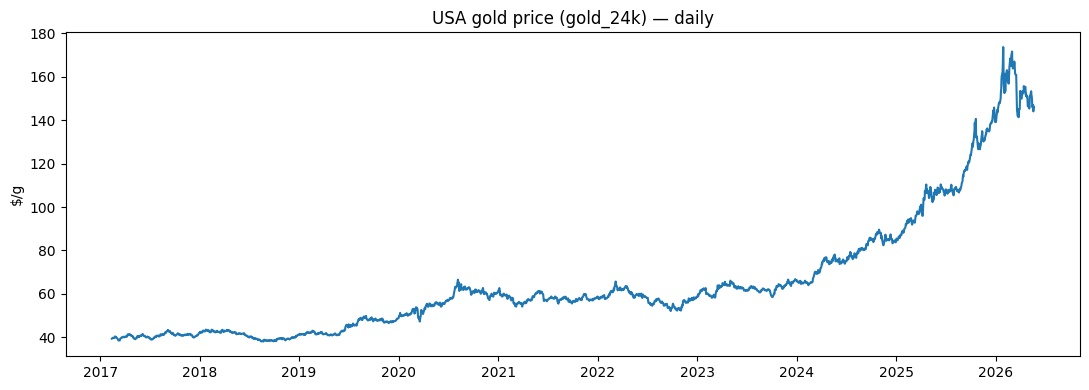

In [3]:
plt.figure(figsize=(11, 4))
plt.plot(s.index, s.values)
plt.title("USA gold price (gold_24k) — daily"); plt.ylabel("$/g")
plt.tight_layout(); plt.show()

## 3. Seasonal–Trend decomposition (STL)
We split the series into **trend**, **seasonal** and **residual** parts. Period = 252 ≈ one year of trading days.

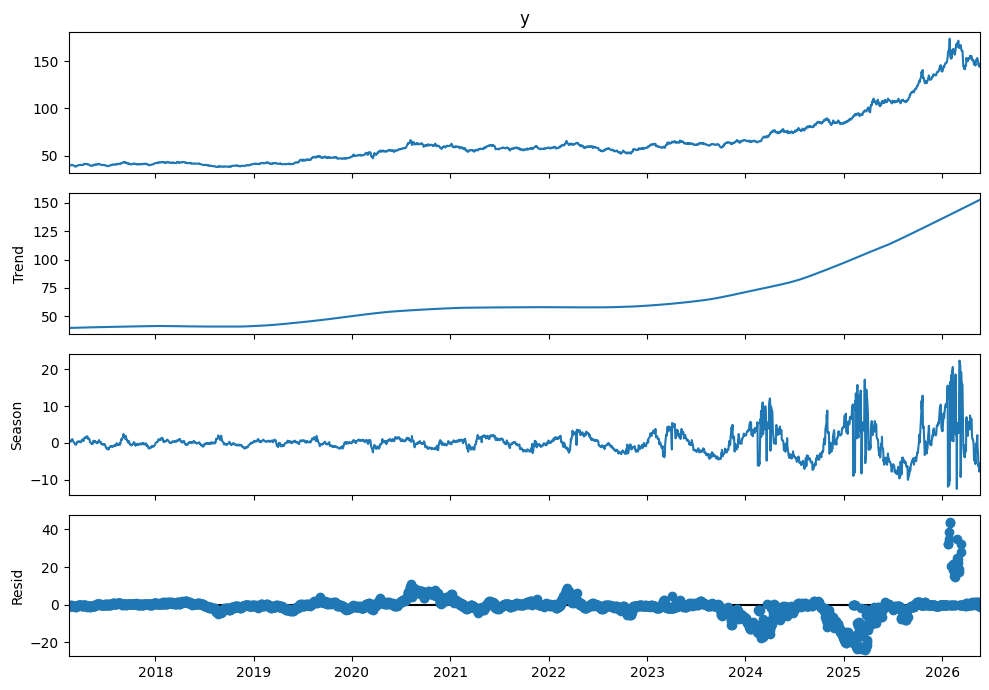

variance share — trend: 0.98  seasonal: 0.014  resid: 0.031


In [4]:
stl = STL(s, period=252, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(10, 7); plt.tight_layout(); plt.show()
print("variance share — trend: %.2f  seasonal: %.3f  resid: %.3f" % (
    stl.trend.var()/s.var(), stl.seasonal.var()/s.var(), stl.resid.var()/s.var()))

## 4. Stationarity — Augmented Dickey–Fuller (ADF)
ADF H0 = *has a unit root* (non-stationary). **p < 0.05 ⇒ stationary.**

In [5]:
log_s = np.log(s)
logret = log_s.diff().dropna()

def adf_row(name, x):
    stat, p = adfuller(x, autolag="AIC")[:2]
    return {"series": name, "ADF stat": round(stat, 3), "p-value": round(p, 4),
            "stationary (p<0.05)": bool(p < 0.05)}

pd.DataFrame([adf_row("level y", s), adf_row("log(y)", log_s),
              adf_row("log-returns", logret)])

,series,ADF stat,p-value,stationary (p<0.05)
0,level y,1.631,0.9979,False
1,log(y),1.363,0.9969,False
2,log-returns,-8.788,0.0000,True


## 5. Transformation for modeling
The level (and log-level) are non-stationary; the **log-returns** are stationary. So one order of differencing on the log price (**d = 1**) makes the series ARIMA-ready. Scaling (e.g. `StandardScaler`) is applied later only for the ML/LSTM notebooks.

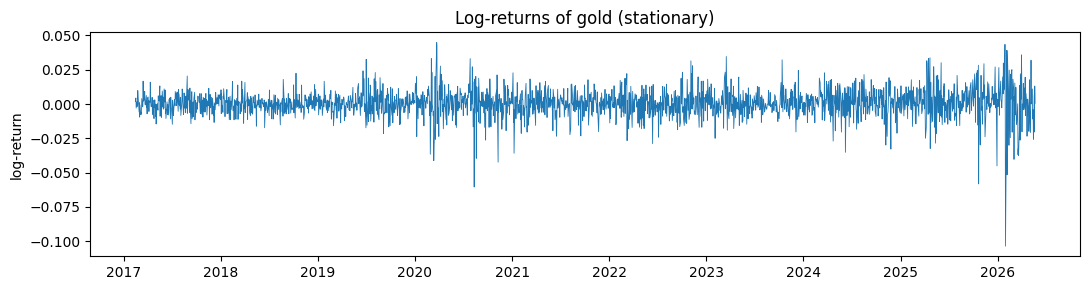

daily log-return: mean=0.00054, std=0.00981 (~0.98%/day)


In [6]:
plt.figure(figsize=(11, 3))
plt.plot(logret.index, logret.values, lw=0.6)
plt.title("Log-returns of gold (stationary)"); plt.ylabel("log-return")
plt.tight_layout(); plt.show()
print(f"daily log-return: mean={logret.mean():.5f}, std={logret.std():.5f} "
      f"(~{logret.std()*100:.2f}%/day)")

## 6. ACF / PACF of log-returns
These guide the ARIMA `(p, q)` orders. Few/no significant lags ⇒ low orders.

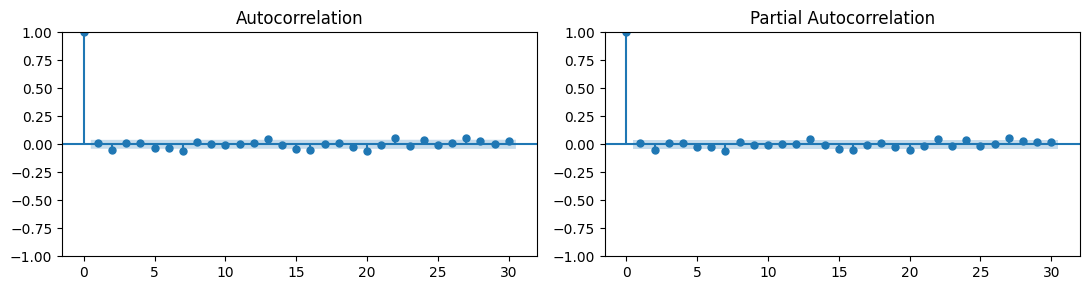

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
plot_acf(logret, lags=30, ax=ax[0]); plot_pacf(logret, lags=30, ax=ax[1], method="ywm")
plt.tight_layout(); plt.show()

## Conclusion
- The price level is **non-stationary** (strong upward trend; ADF p ≈ 1).
- **Log-returns are stationary** (ADF p < 0.05) ⇒ use **d = 1** on the log price.
- ACF/PACF show little autocorrelation ⇒ expect **low ARIMA orders**.
- For the ML/LSTM models we predict the **next-day log-return** and reconstruct the price (notebooks 02–05), which keeps the target stationary and the comparison fair.